# Case iFood - 1. Processamento de Dados (PySpark)

**Objetivo deste notebook:** carregar, limpar e integrar os três conjuntos de dados
(`offers`, `profile`, `transactions`), reconstruindo a jornada de cada oferta enviada
(recebida -> visualizada -> convertida) e produzindo um **dataset unificado** pronto para a
modelagem (notebook 2).

**Granularidade do dataset final:** 1 linha por evento de *oferta recebida* (cliente x oferta x momento do envio),
com o desfecho da oferta (target) e o estado do cliente **no momento do envio** (features sem data leakage).

## Premissas

1. `time_since_test_start` e `duration` estão em **dias**; a janela de validade de uma oferta
   recebida em `t` é `[t, t + duration]`.
2. Em `profile`, `age = 118` co-ocorre com `gender` e `credit_card_limit` nulos - tratamos como
   **cadastro sem dados demográficos** (`age` vira nulo + flag `missing_profile`).
3. **Conversão exige visualização**: uma oferta concluída sem ter sido vista não foi influenciada
   pelo envio - o cliente compraria de qualquer forma e o desconto foi concedido automaticamente.
   Chamamos esse caso de `completed_blind` (desperdício de verba), e ele **não** conta como conversão.
4. Ofertas `informational` não têm evento de conclusão: consideramos conversão quando há **ao menos
   uma transação após a visualização e dentro da validade**.
5. O mesmo cliente pode receber a mesma oferta mais de uma vez (até 5x): cada visualização/conclusão
   é atribuída ao **recebimento ativo mais recente** que a antecede.
6. Como não há data de calendário nas transações, o tempo de casa (`membership_days`) usa a maior
   data de cadastro da base como referência.


In [1]:
import sys
from pathlib import Path

# permite importar src/ tanto rodando da raiz quanto de notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
from pyspark.sql import Window
from pyspark.sql import functions as F

from src.spark_utils import DATA_PROCESSED, DATA_RAW, collect_pd, get_spark
from src.viz import SEQ, SERIES, setup_style

setup_style()
spark = get_spark("ifood-case-1-processing")
print("Spark", spark.version)

Spark 4.1.2


## 1. Carga dos dados brutos

Os três arquivos são JSON em formato de *array* (não JSON Lines), por isso `multiLine=True`.

In [3]:
offers_raw = spark.read.json(str(DATA_RAW / "offers.json"), multiLine=True)
profile_raw = spark.read.json(str(DATA_RAW / "profile.json"), multiLine=True)
tx_raw = spark.read.json(str(DATA_RAW / "transactions.json"), multiLine=True)

print(f"offers:       {offers_raw.count()}")
print(f"profile:      {profile_raw.count()}")
print(f"transactions: {tx_raw.count()}")

offers:       10
profile:      17000
transactions: 306534


In [4]:
# Dataset sobre ofertas
collect_pd(offers_raw.limit(3))

,channels,discount_value,duration,id,min_value,offer_type
0,"[email, mobile, social]",10,7.0,ae264e3637204a6fb9bb56bc8210ddfd,10,bogo
1,"[web, email, mobile, social]",10,5.0,4d5c57ea9a6940dd891ad53e9dbe8da0,10,bogo
2,"[web, email, mobile]",0,4.0,3f207df678b143eea3cee63160fa8bed,0,informational


In [5]:
offers_raw.printSchema()

root
 |-- channels: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- discount_value: long (nullable = true)
 |-- duration: double (nullable = true)
 |-- id: string (nullable = true)
 |-- min_value: long (nullable = true)
 |-- offer_type: string (nullable = true)



In [6]:
# Dataset sobre perfis
collect_pd(profile_raw.limit(3))

,age,credit_card_limit,gender,id,registered_on
0,118,NaN,NaN,68be06ca386d4c31939f3a4f0e3dd783,20170212
1,55,112000.0,F,0610b486422d4921ae7d2bf64640c50b,20170715
2,118,NaN,NaN,38fe809add3b4fcf9315a9694bb96ff5,20180712


In [7]:
profile_raw.printSchema()

root
 |-- age: long (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- id: string (nullable = true)
 |-- registered_on: string (nullable = true)



In [8]:
# Dataset sobre transações
collect_pd(tx_raw.limit(3))

,account_id,event,time_since_test_start,value
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0.0,"{'amount': None, 'offer id': '9b98b8c7a33c4b65..."
1,a03223e636434f42ac4c3df47e8bac43,offer received,0.0,"{'amount': None, 'offer id': '0b1e1539f2cc45b7..."
2,e2127556f4f64592b11af22de27a7932,offer received,0.0,"{'amount': None, 'offer id': '2906b810c7d44117..."


In [9]:
tx_raw.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- event: string (nullable = true)
 |-- time_since_test_start: double (nullable = true)
 |-- value: struct (nullable = true)
 |    |-- amount: double (nullable = true)
 |    |-- offer id: string (nullable = true)
 |    |-- offer_id: string (nullable = true)
 |    |-- reward: double (nullable = true)



## 2. Análise exploratória e qualidade dos dados

### 2.1 Portfólio de ofertas

São apenas 10 ofertas, de 3 tipos: `bogo` (compre 1 leve 2), `discount` e `informational`
(sem desconto - apenas comunicação).

In [10]:
collect_pd(offers_raw.orderBy("offer_type", "min_value", "duration"))

,channels,discount_value,duration,id,min_value,offer_type
0,"[web, email, mobile, social]",5,5.0,f19421c1d4aa40978ebb69ca19b0e20d,5,bogo
1,"[web, email, mobile]",5,7.0,9b98b8c7a33c4b65b9aebfe6a799e6d9,5,bogo
2,"[web, email, mobile, social]",10,5.0,4d5c57ea9a6940dd891ad53e9dbe8da0,10,bogo
3,"[email, mobile, social]",10,7.0,ae264e3637204a6fb9bb56bc8210ddfd,10,bogo
4,"[web, email, mobile, social]",3,7.0,2298d6c36e964ae4a3e7e9706d1fb8c2,7,discount
5,"[web, email, mobile]",2,7.0,2906b810c7d4411798c6938adc9daaa5,10,discount
6,"[web, email, mobile, social]",2,10.0,fafdcd668e3743c1bb461111dcafc2a4,10,discount
7,"[web, email]",5,10.0,0b1e1539f2cc45b7b9fa7c272da2e1d7,20,discount
8,"[email, mobile, social]",0,3.0,5a8bc65990b245e5a138643cd4eb9837,0,informational
9,"[web, email, mobile]",0,4.0,3f207df678b143eea3cee63160fa8bed,0,informational


### 2.2 Clientes (`profile`)

Verificamos o padrão de ausência: `age = 118` marca exatamente os mesmos clientes com
`gender` e `credit_card_limit` nulos.

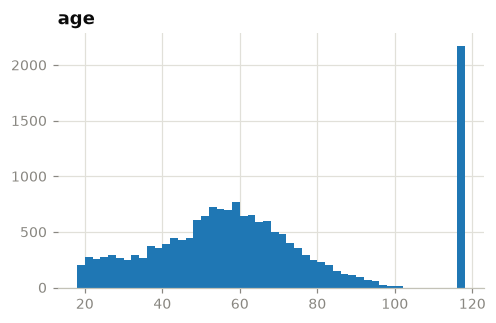

In [11]:
# Distribuição de idade: outlier em 118 anos
collect_pd(profile_raw.select("age")).hist(bins=50, figsize=(5, 3))
plt.show()

In [12]:
# Dataset perfis onde idade é 118 (outlier) e gender/limite são nulos, que é o marcador de cadastro sem demografia
collect_pd(profile_raw.filter(F.col("age") == 118).limit(5))

,age,credit_card_limit,gender,id,registered_on
0,118,None,None,68be06ca386d4c31939f3a4f0e3dd783,20170212
1,118,None,None,38fe809add3b4fcf9315a9694bb96ff5,20180712
2,118,None,None,a03223e636434f42ac4c3df47e8bac43,20170804
3,118,None,None,8ec6ce2a7e7949b1bf142def7d0e0586,20170925
4,118,None,None,68617ca6246f4fbc85e91a2a49552598,20171002


In [13]:
qualidade = profile_raw.select(
    F.count("*").alias("clientes"),
    F.count_distinct("id").alias("ids_distintos"),
    F.sum((F.col("age") == 118).cast("int")).alias("age_118"),
    F.sum(F.col("gender").isNull().cast("int")).alias("gender_nulo"),
    F.sum(F.col("credit_card_limit").isNull().cast("int")).alias("limite_nulo"),
    F.sum(
        (
            (F.col("age") == 118)
            & F.col("gender").isNull()
            & F.col("credit_card_limit").isNull()
        ).cast("int")
    ).alias("os_tres_simultaneos"),
)
display(collect_pd(qualidade))

,clientes,ids_distintos,age_118,gender_nulo,limite_nulo,os_tres_simultaneos
0,17000,17000,2175,2175,2175,2175


In [14]:
display(collect_pd(profile_raw.groupBy("gender").count().orderBy(F.desc("count"))))

,gender,count
0,M,8484
1,F,6129
2,NaN,2175
3,O,212


Os 2.175 casos (12,8%) de demografia ausente são **exatamente os mesmos clientes** nas três
colunas - um único mecanismo de ausência (cadastro incompleto), não três problemas independentes.
Manteremos esses clientes com uma flag em vez de descartá-los: eles recebem ofertas como qualquer
outro e o modelo precisa saber lidar com eles.

### 2.3 Eventos (`transactions`)

O campo `value` é um *struct* inconsistente entre eventos: `offer received`/`offer viewed` usam a
chave **`offer id`** (com espaço), `offer completed` usa **`offer_id`** e traz `reward`;
`transaction` usa apenas `amount`. A limpeza unifica isso.

In [15]:
uso_struct = tx_raw.groupBy("event").agg(
    F.count("*").alias("eventos"),
    F.sum(F.col("value.amount").isNotNull().cast("int")).alias("value.amount"),
    F.sum(F.col("value.`offer id`").isNotNull().cast("int")).alias("value.`offer id`"),
    F.sum(F.col("value.offer_id").isNotNull().cast("int")).alias("value.offer_id"),
    F.sum(F.col("value.reward").isNotNull().cast("int")).alias("value.reward"),
)
collect_pd(uso_struct.orderBy(F.desc("eventos")))

,event,eventos,value.amount,value.`offer id`,value.offer_id,value.reward
0,transaction,138953,138953,0,0,0
1,offer received,76277,0,76277,0,0
2,offer viewed,57725,0,57725,0,0
3,offer completed,33579,0,0,33579,33579


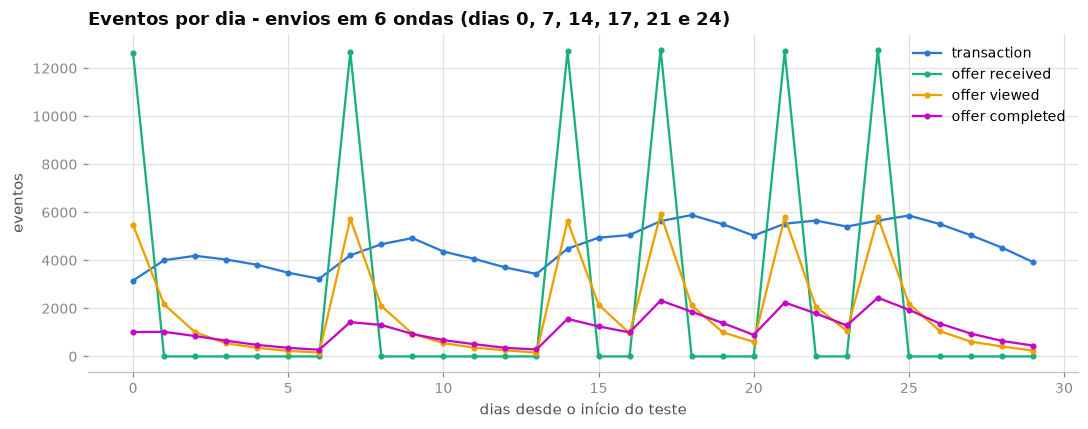

In [16]:
ev_dia = collect_pd(
    tx_raw.groupBy(
        F.floor("time_since_test_start").cast("int").alias("dia"), "event"
    ).count()
)
pv = ev_dia.pivot(index="dia", columns="event", values="count").fillna(0).sort_index()

ordem = ["transaction", "offer received", "offer viewed", "offer completed"]
fig, ax = plt.subplots(figsize=(10, 4))
for i, nome in enumerate(ordem):
    ax.plot(pv.index, pv[nome], color=SERIES[i], linewidth=1.5, marker=".", label=nome)
ax.set_title("Eventos por dia - envios em 6 ondas (dias 0, 7, 14, 17, 21 e 24)")
ax.set_xlabel("dias desde o início do teste")
ax.set_ylabel("eventos")
ax.legend(loc="upper right", ncols=1)
plt.tight_layout()
plt.show()

O teste dura **30 dias** e as ofertas foram enviadas em **6 ondas** (dias 0, 7, 14, 17, 21 e 24),
~12,7 mil clientes por onda. Visualizações e conclusões seguem cada onda com defasagem -
é essa dinâmica temporal que a reconstrução de jornada precisa respeitar.

Quantis do valor da transação (R$):
0.50     8.89
0.75    18.07
0.95    29.91
0.99    40.02


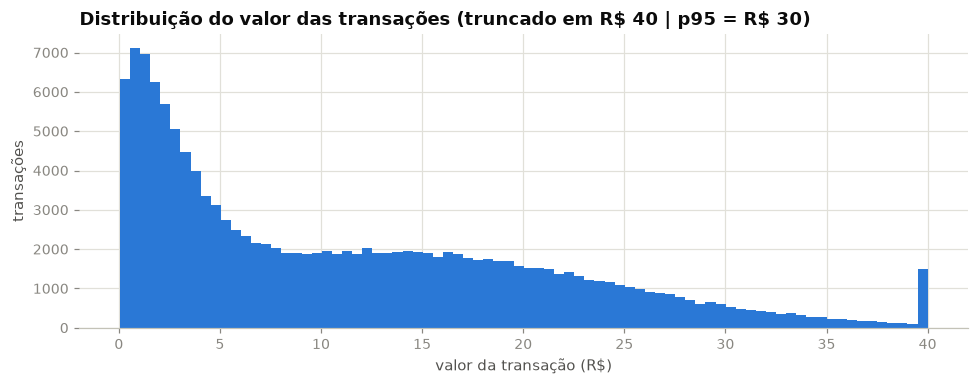

In [17]:
valores = collect_pd(
    tx_raw.filter(F.col("event") == "transaction").select(
        F.col("value.amount").alias("amount")
    )
)
q = valores["amount"].quantile([0.5, 0.75, 0.95, 0.99])
print("Quantis do valor da transação (R$):")
print(q.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(valores["amount"].clip(upper=40), bins=80, color=SERIES[0])
ax.set_title(
    "Distribuição do valor das transações (truncado em R$ 40 | p95 = R$ %.0f)" % q[0.95]
)
ax.set_xlabel("valor da transação (R$)")
ax.set_ylabel("transações")
plt.tight_layout()
plt.show()

## 3. Limpeza e padronização

### 3.1 Ofertas
- `id` -> `offer_id`; canais viram flags binárias (úteis como features).

In [18]:
offers = (
    offers_raw.withColumnRenamed("id", "offer_id")
    .withColumn("duration_days", F.col("duration").cast("double"))
    .withColumn("n_channels", F.size("channels"))
    .withColumn("ch_web", F.array_contains("channels", "web").cast("int"))
    .withColumn("ch_email", F.array_contains("channels", "email").cast("int"))
    .withColumn("ch_mobile", F.array_contains("channels", "mobile").cast("int"))
    .withColumn("ch_social", F.array_contains("channels", "social").cast("int"))
    .drop("duration", "channels")
)
collect_pd(offers.orderBy("offer_type", "min_value"))

,discount_value,offer_id,min_value,offer_type,duration_days,n_channels,ch_web,ch_email,ch_mobile,ch_social
0,5,9b98b8c7a33c4b65b9aebfe6a799e6d9,5,bogo,7.0,3,1,1,1,0
1,5,f19421c1d4aa40978ebb69ca19b0e20d,5,bogo,5.0,4,1,1,1,1
2,10,ae264e3637204a6fb9bb56bc8210ddfd,10,bogo,7.0,3,0,1,1,1
3,10,4d5c57ea9a6940dd891ad53e9dbe8da0,10,bogo,5.0,4,1,1,1,1
4,3,2298d6c36e964ae4a3e7e9706d1fb8c2,7,discount,7.0,4,1,1,1,1
5,2,fafdcd668e3743c1bb461111dcafc2a4,10,discount,10.0,4,1,1,1,1
6,2,2906b810c7d4411798c6938adc9daaa5,10,discount,7.0,3,1,1,1,0
7,5,0b1e1539f2cc45b7b9fa7c272da2e1d7,20,discount,10.0,2,1,1,0,0
8,0,3f207df678b143eea3cee63160fa8bed,0,informational,4.0,3,1,1,1,0
9,0,5a8bc65990b245e5a138643cd4eb9837,0,informational,3.0,3,0,1,1,1


### 3.2 Clientes
- `age = 118` -> nulo + flag `missing_profile`;
- `registered_on` (string `yyyyMMdd`) -> data e tempo de casa em dias.

In [19]:
ref_date = profile_raw.select(F.max(F.to_date("registered_on", "yyyyMMdd"))).first()[0] # data de referência para calcular o tempo de cadastro
print("Data de referência (maior cadastro):", ref_date)

profile = (
    profile_raw.withColumnRenamed("id", "account_id")
    .withColumn("registered_on", F.to_date("registered_on", "yyyyMMdd")) # trata a coluna de data como string no formato yyyyMMdd
    .withColumn("age", F.when(F.col("age") == 118, None).otherwise(F.col("age"))) # trata o outlier de idade 118 como nulo
    .withColumn("missing_profile", F.col("gender").isNull().cast("int")) # marca se o perfil está incompleto (sem gênero)
    .withColumn("membership_days", F.date_diff(F.lit(ref_date), F.col("registered_on"))) # calcula o tempo de cadastro em dias
)
collect_pd(profile.limit(5))

Data de referência (maior cadastro): 2018-07-26


,age,credit_card_limit,gender,account_id,registered_on,missing_profile,membership_days
0,NaN,NaN,NaN,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,1,529
1,55.0,112000.0,F,0610b486422d4921ae7d2bf64640c50b,2017-07-15,0,376
2,NaN,NaN,NaN,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,1,14
3,75.0,100000.0,F,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,0,443
4,NaN,NaN,NaN,a03223e636434f42ac4c3df47e8bac43,2017-08-04,1,356


### 3.3 Eventos
- Unificamos `value['offer id']` / `value.offer_id` em uma única coluna;
- `t_idx` converte o tempo (passos de 0,25 dia = 6h) em índice **inteiro**, o que permite janelas
  temporais exatas sem aritmética de ponto flutuante.

In [20]:
# Achata o struct value em colunas simples, uma linha por evento:
# - offer_id: offer completed grava em value.offer_id; received/viewed usam
#   value.offer id (com espaço) -> o coalesce unifica as duas grafias
# - t_idx: o tempo anda em passos de 0,25 dia (6h); como índice INTEIRO permite
#   janelas exatas ("estritamente antes") sem comparação de ponto flutuante
tx = tx_raw.select(
    "account_id",
    "event",
    F.col("time_since_test_start").alias("t"),
    F.coalesce(F.col("value.offer_id"), F.col("value.`offer id`")).alias("offer_id"),
    F.col("value.amount").alias("amount"),
    F.col("value.reward").alias("reward"),
).withColumn("t_idx", F.round(F.col("t") * 4).cast("int"))
tx.cache()

# checagem: após o coalesce, nenhum evento de oferta fica sem offer_id
collect_pd(
    tx.groupBy("event")
    .agg(
        F.count("*").alias("eventos"),
        F.count_distinct("account_id").alias("clientes"),
        F.sum(F.col("offer_id").isNull().cast("int")).alias("offer_id_nulo"),
    )
    .orderBy(F.desc("eventos"))
)

,event,eventos,clientes,offer_id_nulo
0,transaction,138953,16578,138953
1,offer received,76277,16994,0
2,offer viewed,57725,16834,0
3,offer completed,33579,12774,0


## 4. Features de comportamento histórico

Para cada evento, calculamos agregados do que o cliente fez **estritamente antes** daquele momento
(janela `rangeBetween(unboundedPreceding, -1)` sobre `t_idx`). Ao filtrar os eventos de
`offer received`, cada linha carrega o estado do cliente **no instante do envio** - nada do futuro
vaza para as features, um cuidado essencial para o modelo ser utilizável em produção.

In [21]:
# Janela de HISTÓRICO por cliente: tudo que aconteceu ESTRITAMENTE ANTES do evento.
# - partitionBy(account_id): o passado de um cliente não se mistura com o de outro
# - orderBy(t_idx) + rangeBetween(unboundedPreceding, -1): considera eventos até
#   t_idx - 1; eventos do MESMO instante ficam de fora (ex.: uma compra simultânea
#   ao envio não entra nas features daquele envio) -> zero data leakage
w_hist = (
    Window.partitionBy("account_id")
    .orderBy("t_idx")
    .rangeBetween(Window.unboundedPreceding, -1)
)

e = F.col("event")

# Acumula o comportamento do cliente ATÉ cada evento. O coalesce(..., 0) cobre o
# primeiro evento de cada cliente: sem passado, a soma da janela é nula -> vira 0.
events_hist = (
    # nº de compras feitas antes deste evento
    tx.withColumn(
        "hist_n_tx",
        F.coalesce(F.sum((e == "transaction").cast("int")).over(w_hist), F.lit(0)),
    )
    # gasto acumulado antes deste evento (soma o amount só das transações)
    .withColumn(
        "hist_spend",
        F.coalesce(
            F.sum(F.when(e == "transaction", F.col("amount"))).over(w_hist), F.lit(0.0)
        ),
    )
    # exposição prévia a ofertas: quantas recebeu / visualizou / concluiu até aqui
    .withColumn(
        "hist_n_received",
        F.coalesce(F.sum((e == "offer received").cast("int")).over(w_hist), F.lit(0)),
    )
    .withColumn(
        "hist_n_viewed",
        F.coalesce(F.sum((e == "offer viewed").cast("int")).over(w_hist), F.lit(0)),
    )
    .withColumn(
        "hist_n_completed",
        F.coalesce(F.sum((e == "offer completed").cast("int")).over(w_hist), F.lit(0)),
    )
    # instante da última compra antes deste evento -> vira a recência
    # (days_since_last_tx) na seção 5.1
    .withColumn(
        "last_tx_idx", F.max(F.when(e == "transaction", F.col("t_idx"))).over(w_hist)
    )
)

In [22]:
# Linha do tempo de um cliente: as colunas hist_* acumulam SÓ o que veio antes de
# cada evento (uma compra em t entra nos contadores apenas dos eventos seguintes)
collect_pd(events_hist.orderBy("account_id", "t_idx").limit(10))

,account_id,event,t,offer_id,amount,reward,t_idx,hist_n_tx,hist_spend,hist_n_received,hist_n_viewed,hist_n_completed,last_tx_idx
0,0009655768c64bdeb2e877511632db8f,offer received,7.00,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,28,0,0.00,0,0,0,NaN
1,0009655768c64bdeb2e877511632db8f,offer viewed,8.00,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,32,0,0.00,1,0,0,NaN
2,0009655768c64bdeb2e877511632db8f,transaction,9.50,NaN,22.16,NaN,38,0,0.00,1,1,0,NaN
3,0009655768c64bdeb2e877511632db8f,offer received,14.00,3f207df678b143eea3cee63160fa8bed,NaN,NaN,56,1,22.16,1,1,0,38.0
4,0009655768c64bdeb2e877511632db8f,offer viewed,15.50,3f207df678b143eea3cee63160fa8bed,NaN,NaN,62,1,22.16,2,1,0,38.0
5,0009655768c64bdeb2e877511632db8f,offer received,17.00,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,68,1,22.16,2,2,0,38.0
6,0009655768c64bdeb2e877511632db8f,transaction,17.25,NaN,8.57,NaN,69,1,22.16,3,2,0,38.0
7,0009655768c64bdeb2e877511632db8f,offer completed,17.25,f19421c1d4aa40978ebb69ca19b0e20d,NaN,5.0,69,1,22.16,3,2,0,38.0
8,0009655768c64bdeb2e877511632db8f,offer viewed,19.00,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,76,2,30.73,3,2,1,69.0
9,0009655768c64bdeb2e877511632db8f,offer received,21.00,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,84,2,30.73,3,3,1,69.0


## 5. Reconstrução da jornada de cada oferta enviada

### 5.1 Recebimentos (granularidade do dataset)

Cada linha de `offer received` vira um "recebimento" com identificador próprio, janela de validade
e metadados da oferta.

In [23]:
# contadores da seção 4 que entram direto no dataset
feature_cols = [
    "hist_n_tx",
    "hist_spend",
    "hist_n_received",
    "hist_n_viewed",
    "hist_n_completed",
]

# O grão do dataset nasce aqui: cada evento offer received vira um "recebimento",
# carregando o estado do cliente NO MOMENTO DO ENVIO (features da seção 4).
receipts = (
    events_hist.filter(e == "offer received")
    .select(
        "account_id",
        "offer_id",
        F.col("t").alias("t_received"),
        *feature_cols,
        # ticket médio histórico; 'when(> 0)' evita divisão por zero: cliente sem
        # compra prévia fica NULO (desconhecido), não um 0 enganoso
        F.when(F.col("hist_n_tx") > 0, F.col("hist_spend") / F.col("hist_n_tx")).alias(
            "hist_avg_ticket"
        ),
        # recência: dias desde a última compra; NULO = nunca comprou até aqui
        F.when(
            F.col("last_tx_idx").isNotNull(),
            (F.col("t_idx") - F.col("last_tx_idx")) / F.lit(4.0),
        ).alias("days_since_last_tx"),
        # engajamento histórico com ofertas: fração das recebidas que viu / recebidas
        F.when(
            F.col("hist_n_received") > 0,
            F.col("hist_n_viewed") / F.col("hist_n_received"),
        ).alias("hist_view_rate"),
        F.when(
            F.col("hist_n_received") > 0,
            F.col("hist_n_completed") / F.col("hist_n_received"),
        ).alias("hist_comp_rate"),
    )
    # anexa os atributos da oferta enviada (tipo, desconto, mínimo, duração, canais)
    .join(offers, "offer_id", "left")
    # janela de validade deste recebimento: [t_received, t_expiry]
    .withColumn("t_expiry", F.col("t_received") + F.col("duration_days"))
    # id único e determinístico por recebimento: é a chave que permite devolver
    # visualizações/conclusões à janela certa quando a MESMA oferta foi recebida 2x+
    .withColumn(
        "receipt_id",
        F.row_number().over(Window.orderBy("account_id", "offer_id", "t_received")),
    )
)
receipts.cache()

n_receipts = receipts.count()
print(f"recebimentos: {n_receipts:,}")
assert receipts.filter(F.col("offer_type").isNull()).count() == 0, (
    "recebimento sem oferta no portfólio"
)

recebimentos: 76,277


In [24]:
# amostra: 1 linha por recebimento (cliente x oferta x momento do envio)
collect_pd(receipts.orderBy("receipt_id").limit(3))

,offer_id,account_id,t_received,hist_n_tx,hist_spend,hist_n_received,hist_n_viewed,hist_n_completed,hist_avg_ticket,days_since_last_tx,...,min_value,offer_type,duration_days,n_channels,ch_web,ch_email,ch_mobile,ch_social,t_expiry,receipt_id
0,2906b810c7d4411798c6938adc9daaa5,0009655768c64bdeb2e877511632db8f,24.0,4,58.40,4,4,2,14.60,1.0,...,10,discount,7.0,3,1,1,1,0,31.0,1
1,3f207df678b143eea3cee63160fa8bed,0009655768c64bdeb2e877511632db8f,14.0,1,22.16,1,1,0,22.16,4.5,...,0,informational,4.0,3,1,1,1,0,18.0,2
2,5a8bc65990b245e5a138643cd4eb9837,0009655768c64bdeb2e877511632db8f,7.0,0,0.00,0,0,0,NaN,NaN,...,0,informational,3.0,3,0,1,1,1,10.0,3


### 5.2 Visualizações e conclusões dentro da janela

Como o mesmo cliente pode ter a mesma oferta ativa mais de uma vez, atribuímos cada
visualização/conclusão ao **recebimento ativo mais recente** e, por recebimento,
guardamos a **primeira** ocorrência.

In [25]:
# versão enxuta dos recebimentos: só o necessário para casar eventos com janelas
rec_slim = receipts.select(
    "receipt_id", "account_id", "offer_id", "t_received", "t_expiry"
)

views = tx.filter(e == "offer viewed").select(
    "account_id", "offer_id", F.col("t").alias("t_view")
)

# Uma visualização só conta se cair DENTRO da validade de um recebimento da mesma oferta.
# Como o cliente pode ter a mesma oferta ativa 2x (janelas sobrepostas), a
# view pode casar com mais de um recebimento -> o row_number ordenado por
# t_received DESC mantém apenas o recebimento ativo MAIS RECENTE (premissa 5).
view_attr = (
    views.join(rec_slim, ["account_id", "offer_id"])
    .filter(
        (F.col("t_view") >= F.col("t_received"))
        & (F.col("t_view") <= F.col("t_expiry"))
    )
    .withColumn(
        "rn",
        F.row_number().over(
            Window.partitionBy("account_id", "offer_id", "t_view").orderBy(
                F.col("t_received").desc()
            )
        ),
    )
    .filter(F.col("rn") == 1)
)

# por recebimento, interessa a PRIMEIRA visualização: marca o início da influência
# da oferta sobre o cliente (usada na atribuição do target, seção 5.4)
first_view = view_attr.groupBy("receipt_id").agg(F.min("t_view").alias("t_first_view"))

n_views = views.count()
print(
    f"visualizações: {n_views:,} | atribuídas a uma janela ativa: {view_attr.count():,}"
)

visualizações: 57,725 | atribuídas a uma janela ativa: 56,567


In [26]:
# janelas de validade usadas no casamento dos eventos
collect_pd(rec_slim.orderBy("receipt_id").limit(3))

,receipt_id,account_id,offer_id,t_received,t_expiry
0,1,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,24.0,31.0
1,2,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,14.0,18.0
2,3,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,7.0,10.0


In [27]:
# primeira visualização atribuída a cada recebimento
collect_pd(first_view.orderBy("receipt_id").limit(3))

,receipt_id,t_first_view
0,2,15.5
1,3,8.0
2,4,19.0


In [28]:
# Conclusões: mesma lógica de atribuição das visualizações, com um dado a mais,
# o 'reward' (desconto efetivamente pago quando a oferta foi concluída).
comps = tx.filter(e == "offer completed").select(
    "account_id", "offer_id", F.col("t").alias("t_complete"), "reward"
)
comp_attr = (
    comps.join(rec_slim, ["account_id", "offer_id"])
    .filter(
        (F.col("t_complete") >= F.col("t_received"))
        & (F.col("t_complete") <= F.col("t_expiry"))
    )
    .withColumn(
        "rn",
        F.row_number().over(
            Window.partitionBy("account_id", "offer_id", "t_complete").orderBy(
                F.col("t_received").desc()
            )
        ),
    )
    .filter(F.col("rn") == 1)
)

# por recebimento: instante da primeira conclusão e o reward pago nela
# (min_by = reward da linha com menor t_complete)
first_comp = comp_attr.groupBy("receipt_id").agg(
    F.min("t_complete").alias("t_completion"),
    F.min_by("reward", "t_complete").alias("reward_received"),
)

# controles: praticamente toda conclusão casa com uma janela ativa; os "empates"
# são o caso raro de a mesma oferta ativa 2x ser concluída no mesmo instante
n_comps = comps.count()
n_comps_dist = comps.dropDuplicates(["account_id", "offer_id", "t_complete"]).count()
print(
    f"conclusões: {n_comps:,} | instantes distintos: {n_comps_dist:,} | atribuídas: {comp_attr.count():,}"
)
print(
    f"conclusões simultâneas (mesma oferta ativa 2x): {n_comps - n_comps_dist:,} - atribuídas ao recebimento mais recente"
)

conclusões: 33,579 | instantes distintos: 33,182 | atribuídas: 33,182
conclusões simultâneas (mesma oferta ativa 2x): 397 - atribuídas ao recebimento mais recente


In [29]:
# conclusões já casadas à janela ativa (rn = 1 -> recebimento mais recente)
collect_pd(comp_attr.orderBy("receipt_id").limit(3))

,account_id,offer_id,t_complete,reward,receipt_id,t_received,t_expiry,rn
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,24.00,2.0,1,24.0,31.0,1
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,17.25,5.0,4,17.0,22.0,1
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,22.00,2.0,5,21.0,31.0,1


In [30]:
# primeira conclusão e reward pago, por recebimento
collect_pd(first_comp.orderBy("receipt_id").limit(3))

,receipt_id,t_completion,reward_received
0,1,24.00,2.0
1,4,17.25,5.0
2,5,22.00,2.0


### 5.3 Conversão de ofertas informacionais e gasto na janela

- `informational`: conversão = transação entre a primeira visualização e o fim da validade;
- `window_spend`: gasto total do cliente durante a validade da oferta - **coluna de desfecho**
  (usada para dimensionar impacto), nunca como feature.

In [31]:
txn = tx.filter(e == "transaction").select(
    "account_id", F.col("t").alias("t_tx"), "amount"
)

# Gasto do cliente DURANTE a validade de cada oferta. É coluna de DESFECHO (mede o
# que aconteceu depois do envio): serve para dimensionar impacto no notebook 2.
window_spend = (
    rec_slim.join(txn, "account_id")
    .filter(
        (F.col("t_tx") >= F.col("t_received")) & (F.col("t_tx") <= F.col("t_expiry"))
    )
    .groupBy("receipt_id")
    .agg(F.sum("amount").alias("window_spend"), F.count("*").alias("window_n_tx"))
)

# Ofertas informacionais não geram evento offer completed. Definimos conversão
# como: o cliente VIU a oferta (join com first_view é inner de propósito) e fez ao
# menos uma transação entre a visualização e o vencimento. O distinct() garante
# 1 linha por recebimento mesmo com várias transações na janela.
info_conv = (
    receipts.filter(F.col("offer_type") == "informational")
    .join(first_view, "receipt_id")
    .select("receipt_id", "account_id", "t_first_view", "t_expiry")
    .join(txn, "account_id")
    .filter(
        (F.col("t_tx") >= F.col("t_first_view")) & (F.col("t_tx") <= F.col("t_expiry"))
    )
    .select("receipt_id")
    .distinct()
    .withColumn("info_converted", F.lit(1))
)
print(f"conversões informacionais: {info_conv.count():,}")

conversões informacionais: 5,954


In [32]:
# transações achatadas usadas nos cruzamentos por janela
collect_pd(txn.limit(3))

,account_id,t_tx,amount
0,02c083884c7d45b39cc68e1314fec56c,0.0,0.83
1,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,0.0,34.56
2,54890f68699049c2a04d415abc25e717,0.0,13.23


In [33]:
# gasto total dentro da validade, por recebimento (coluna de desfecho)
collect_pd(window_spend.orderBy("receipt_id").limit(3))

,receipt_id,window_spend,window_n_tx
0,1,69.20,4
1,2,8.57,1
2,3,22.16,1


In [34]:
# recebimentos informacionais convertidos (viu + transacionou dentro da validade)
collect_pd(info_conv.orderBy("receipt_id").limit(3))

,receipt_id,info_converted
0,2,1
1,3,1
2,19,1


### 5.4 Montagem da jornada e definição do target

`converted` (target):
- `bogo`/`discount`: concluída **após** a primeira visualização, dentro da validade;
- `informational`: transação após a visualização, dentro da validade.

`completed_blind`: concluída sem visualização prévia - desconto concedido sem influência do envio.

In [35]:
# Junta os desfechos de volta ao grão de recebimentos. LEFT joins de propósito:
# recebimento sem visualização/conclusão permanece no dataset com flags 0 - esses
# "negativos" são exatamente o que o modelo precisa para aprender quem NÃO responde.
journey = (
    receipts.join(first_view, "receipt_id", "left")
    .join(first_comp, "receipt_id", "left")
    .join(info_conv, "receipt_id", "left")
    .join(window_spend, "receipt_id", "left")
    .withColumn("viewed", F.col("t_first_view").isNotNull().cast("int"))
    .withColumn("completed", F.col("t_completion").isNotNull().cast("int"))
    # TARGET converted:
    # - informational: viu e transacionou dentro da validade (seção 5.3)
    # - bogo/discount: concluiu DEPOIS de ver (t_first_view <= t_completion);
    #   conclusão sem visualização prévia NÃO conta - é compra que aconteceria
    #   de qualquer forma (premissa 3)
    .withColumn(
        "converted",
        F.when(
            F.col("offer_type") == "informational",
            F.coalesce(F.col("info_converted"), F.lit(0)),
        ).otherwise(
            (
                (F.col("completed") == 1)
                & (F.col("viewed") == 1)
                & (F.col("t_first_view") <= F.col("t_completion"))
            ).cast("int")
        ),
    )
    # concluiu sem ter visto: desconto pago sem influência do envio (desperdício)
    .withColumn(
        "completed_blind",
        ((F.col("completed") == 1) & (F.col("converted") == 0)).cast("int"),
    )
    # desfechos numéricos: quem não casou nos left joins não gastou na janela -> 0
    .withColumn("window_spend", F.coalesce(F.col("window_spend"), F.lit(0.0)))
    .withColumn("window_n_tx", F.coalesce(F.col("window_n_tx"), F.lit(0)))
    .drop("info_converted")
)

In [36]:
# jornada completa; t_first_view/t_completion nulos = etapa não aconteceu
collect_pd(journey.orderBy("receipt_id").limit(3))

,receipt_id,offer_id,account_id,t_received,hist_n_tx,hist_spend,hist_n_received,hist_n_viewed,hist_n_completed,hist_avg_ticket,...,t_expiry,t_first_view,t_completion,reward_received,window_spend,window_n_tx,viewed,completed,converted,completed_blind
0,1,2906b810c7d4411798c6938adc9daaa5,0009655768c64bdeb2e877511632db8f,24.0,4,58.40,4,4,2,14.60,...,31.0,NaN,24.0,2.0,69.20,4,0,1,0,1
1,2,3f207df678b143eea3cee63160fa8bed,0009655768c64bdeb2e877511632db8f,14.0,1,22.16,1,1,0,22.16,...,18.0,15.5,NaN,NaN,8.57,1,1,0,1,0
2,3,5a8bc65990b245e5a138643cd4eb9837,0009655768c64bdeb2e877511632db8f,7.0,0,0.00,0,0,0,NaN,...,10.0,8.0,NaN,NaN,22.16,1,1,0,1,0


In [37]:
journey.printSchema()

root
 |-- receipt_id: integer (nullable = false)
 |-- offer_id: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- t_received: double (nullable = true)
 |-- hist_n_tx: long (nullable = false)
 |-- hist_spend: double (nullable = false)
 |-- hist_n_received: long (nullable = false)
 |-- hist_n_viewed: long (nullable = false)
 |-- hist_n_completed: long (nullable = false)
 |-- hist_avg_ticket: double (nullable = true)
 |-- days_since_last_tx: double (nullable = true)
 |-- hist_view_rate: double (nullable = true)
 |-- hist_comp_rate: double (nullable = true)
 |-- discount_value: long (nullable = true)
 |-- min_value: long (nullable = true)
 |-- offer_type: string (nullable = true)
 |-- duration_days: double (nullable = true)
 |-- n_channels: integer (nullable = true)
 |-- ch_web: integer (nullable = true)
 |-- ch_email: integer (nullable = true)
 |-- ch_mobile: integer (nullable = true)
 |-- ch_social: integer (nullable = true)
 |-- t_expiry: double (nullable = true)
 

## 6. Dataset unificado e validações

In [38]:
# dataset final = jornada da oferta + atributos do cliente
unified = journey.join(
    profile.select(
        "account_id",
        "age",
        "gender",
        "credit_card_limit",
        "membership_days",
        "missing_profile",
    ),
    "account_id",
    "left",
)
unified.cache()

n_unified = unified.count()
# o join com profile não pode criar nem perder linhas (account_id é único lá)
assert n_unified == n_receipts, (
    f"perda/duplicação de linhas: {n_unified} != {n_receipts}"
)
# unicidade da granularidade: exatamente 1 linha por recebimento
assert unified.select("receipt_id").distinct().count() == n_unified, (
    "receipt_id duplicado"
)
# todo recebimento tem target definido
assert unified.filter(F.col("converted").isNull()).count() == 0, "target nulo"
# todo evento aponta para um cliente presente no cadastro
assert unified.filter(F.col("membership_days").isNull()).count() == 0, (
    "cliente sem perfil"
)
# nenhuma conclusão atribuída fora da janela de validade do seu recebimento
bad_window = unified.filter(
    (F.col("t_completion") < F.col("t_received"))
    | (F.col("t_completion") > F.col("t_expiry"))
)
assert bad_window.count() == 0, "conclusão fora da janela de validade"
print(f"{n_unified:,} linhas, 1 por oferta recebida")

resumo = unified.groupBy("offer_type").agg(
    F.count("*").alias("enviadas"),
    F.round(F.avg("viewed"), 3).alias("taxa_visualizacao"),
    F.round(F.avg("completed"), 3).alias("taxa_conclusao"),
    F.round(F.avg("converted"), 3).alias("taxa_conversao"),
    F.round(F.avg("completed_blind"), 3).alias("taxa_conclusao_cega"),
)
collect_pd(resumo.orderBy("offer_type"))

76,277 linhas, 1 por oferta recebida


,offer_type,enviadas,taxa_visualizacao,taxa_conclusao,taxa_conversao,taxa_conclusao_cega
0,bogo,30499,0.828,0.508,0.359,0.150
1,discount,30543,0.700,0.576,0.404,0.173
2,informational,15235,0.653,0.000,0.391,0.000


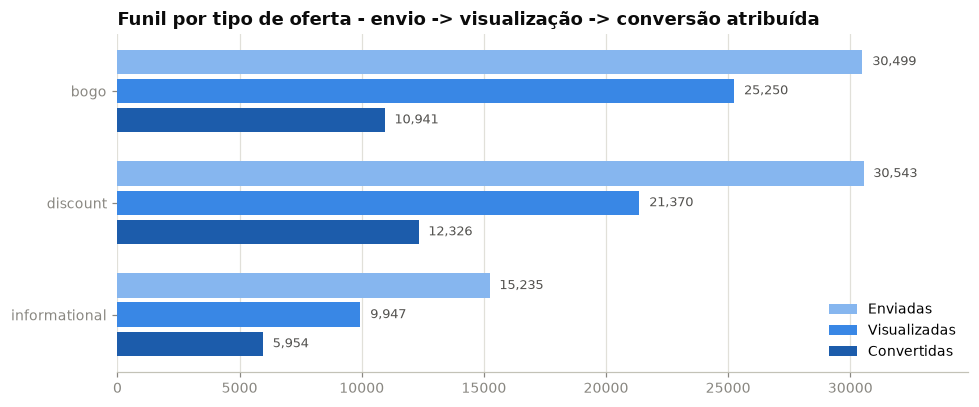

In [39]:
import numpy as np

funil = collect_pd(
    unified.groupBy("offer_type")
    .agg(
        F.count("*").alias("Enviadas"),
        F.sum("viewed").alias("Visualizadas"),
        F.sum("converted").alias("Convertidas"),
    )
    .orderBy("offer_type")
)

tipos = funil["offer_type"].tolist()
etapas = ["Enviadas", "Visualizadas", "Convertidas"]
y = np.arange(len(tipos))
h = 0.26

fig, ax = plt.subplots(figsize=(9, 3.8))
for i, etapa in enumerate(etapas):
    vals = funil[etapa]
    ax.barh(y - h + i * h, vals, height=h - 0.04, color=SEQ[i], label=etapa)
    for yi, v in zip(y - h + i * h, vals):
        ax.text(v + 400, yi, f"{v:,.0f}", va="center", fontsize=8.5, color="#52514e")
ax.set_yticks(y, tipos)
ax.set_xlim(0, funil["Enviadas"].max() * 1.14)
ax.invert_yaxis()
ax.set_title("Funil por tipo de oferta - envio -> visualização -> conversão atribuída")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

A visualização é o gargalo do funil e depende fortemente dos canais de cada oferta. Nas ofertas com
desconto, parte relevante das conclusões é "cega" (sem visualização) - desconto pago a quem
compraria de qualquer forma. Esses dois fatos motivam a solução do notebook 2: **enviar a oferta
certa para cada cliente**, considerando a chance de resposta de cada um.



## 7. Escrita dos dados processados

In [40]:
# repartition(4): dataset pequeno -> poucos arquivos parquet de tamanho razoável
unified.repartition(4).write.mode("overwrite").parquet(
    str(DATA_PROCESSED / "unified_dataset.parquet")
)
offers.write.mode("overwrite").parquet(str(DATA_PROCESSED / "offers.parquet"))
profile.write.mode("overwrite").parquet(str(DATA_PROCESSED / "profile.parquet"))
tx.write.mode("overwrite").parquet(str(DATA_PROCESSED / "transactions_clean.parquet"))

# releitura como verificação final do artefato que o notebook 2 consome
check = spark.read.parquet(str(DATA_PROCESSED / "unified_dataset.parquet"))
print(
    f"unified_dataset.parquet: {check.count():,} linhas x {len(check.columns)} colunas"
)
print(sorted(check.columns))

unified_dataset.parquet: 76,277 linhas x 37 colunas
['account_id', 'age', 'ch_email', 'ch_mobile', 'ch_social', 'ch_web', 'completed', 'completed_blind', 'converted', 'credit_card_limit', 'days_since_last_tx', 'discount_value', 'duration_days', 'gender', 'hist_avg_ticket', 'hist_comp_rate', 'hist_n_completed', 'hist_n_received', 'hist_n_tx', 'hist_n_viewed', 'hist_spend', 'hist_view_rate', 'membership_days', 'min_value', 'missing_profile', 'n_channels', 'offer_id', 'offer_type', 'receipt_id', 'reward_received', 't_completion', 't_expiry', 't_first_view', 't_received', 'viewed', 'window_n_tx', 'window_spend']


## Resumo

| Saída | Conteúdo |
|---|---|
| `data/processed/unified_dataset.parquet` | 1 linha por oferta recebida: jornada + target `converted` + features do cliente no momento do envio |
| `data/processed/offers.parquet` | portfólio limpo (canais como flags) |
| `data/processed/profile.parquet` | clientes limpos (`age=118` -> nulo, `missing_profile`, tempo de casa) |
| `data/processed/transactions_clean.parquet` | eventos achatados e padronizados |

**Decisões-chave:** target com atribuição (conversão exige visualização), tratamento de recebimentos
repetidos da mesma oferta e features históricas calculadas apenas com o passado de cada envio
(sem data leakage). O notebook 2 usa este dataset para treinar o modelo de propensão e construir a
política de recomendação de ofertas.

In [41]:
spark.stop()